# NHIES Data Analysis for Micronutrient Fortification Strategy
## Prepared by Aaron Wise; aaronbwise@gmail.com
### Version: 14 June 2020

In [3]:
import os

import numpy as np

import pandas as pd
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from scipy import stats

from aw_analytics import mean_wt, output_mean_table

In [4]:
path = './data/NHEIS_2015_16_household_level_labelled.csv'

df = pd.read_csv(path)
df.shape

(10090, 2530)

## Data Cleaning

In [4]:
# Clean q02_58_1-15 - replace 'yes' with 1, 'no' with 0
cols = ["q02_58_01","q02_58_02","q02_58_04","q02_58_13","q02_58_15"]
df[cols] = df[cols].replace({'yes':1, 'no':0})

# Clean q07_02_1-5 - replace NaN with 0; 'checked' with 1; 'unchecked' with 0
cols = ['q07_02_1', 'q07_02_2', 'q07_02_3', 'q07_02_4', 'q07_02_5']
df[cols] = df[cols].replace({'checked': 1, 'unchecked': 0, np.nan: 0})

cols = ['q07_02_6']
df[cols] = df[cols].replace({'yes': 1, 0.0: 0, '0': 0})

# Clean q07_08_3 - 'checked' with 1; 'unchecked' with 0
cols = ['q07_08_3']
df[cols] = df[cols].replace({'checked': 1, 'unchecked': 0})

In [5]:
# Binarize categorical variables
# Clean categorical variable values - remove ',', ' ', etc.
cols = ['q02_60_01', 'q02_60_02', 'q02_60_04', 'q02_60_13', 'q02_60_15']
df[cols] = df[cols].apply(lambda x: x.str.strip().str.lower().str.replace(',', '_')\
                          .str.replace(' ', '_').str.replace('/', '_').\
                          str.replace('(', '').str.replace(')', ''))

# q02_60_01 -> wheat flour
main_source_wheat_bin = pd.get_dummies(df['q02_60_01'], prefix='main_source_wheat')
df = df[:].join(main_source_wheat_bin)

# q02_60_02 -> other cereals
main_source_other_bin = pd.get_dummies(df['q02_60_02'], prefix='main_source_other')
df = df[:].join(main_source_other_bin)

# q02_60_04 -> rice
main_source_rice_bin = pd.get_dummies(df['q02_60_04'], prefix='main_source_rice')
df = df[:].join(main_source_rice_bin)

# q02_60_13 -> oil/fats
main_source_oil_bin = pd.get_dummies(df['q02_60_13'], prefix='main_source_oil')
df = df[:].join(main_source_oil_bin)

# q02_60_15 -> spices
main_source_spices_bin = pd.get_dummies(df['q02_60_15'], prefix='main_source_spices')
df = df[:].join(main_source_spices_bin)

# Replace NaN
# Wheat flour / bread
idx = df.columns.get_loc("main_source_wheat_asking_for_help_from_others")
cols = list(df.iloc[:,idx:(idx+11)])
df.loc[df['q02_58_01'] == 0, cols] = np.nan

# Other cereal
idx = df.columns.get_loc("main_source_other_asking_for_help_from_others")
cols = list(df.iloc[:,idx:(idx+11)])
df.loc[df['q02_58_02'] == 0, cols] = np.nan

# Rice
idx = df.columns.get_loc("main_source_rice_asking_for_help_from_others")
cols = list(df.iloc[:,idx:(idx+11)])
df.loc[df['q02_58_04'] == 0, cols] = np.nan

# Oils/fats
idx = df.columns.get_loc("main_source_oil_asking_for_help_from_others")
cols = list(df.iloc[:,idx:(idx+11)])
df.loc[df['q02_58_13'] == 0, cols] = np.nan

# Spices
idx = df.columns.get_loc("main_source_spices_asking_for_help_from_others")
cols = list(df.iloc[:,idx:(idx+11)])
df.loc[df['q02_58_15'] == 0, cols] = np.nan


In [6]:
# Create new variables

# Age of Household Head -> Categories
conditions = [
    (df['age_of_head'] < 18),
    (df['age_of_head'] >= 18) & (df['age_of_head'] < 60),
    (df['age_of_head'] >= 60)]
choices = ['0-18', '18-59', '60+']
df['age_of_head_cat'] = np.select(conditions, choices)

# Househould consumed wheat flour and/or rice
conditions = [
     (df['q02_58_01'].eq(1)) & (df['q02_58_04'].eq(1)),
     (df['q02_58_01'].eq(1)) | (df['q02_58_04'].eq(1)),
     (df['q02_58_01'].eq(0)) & (df['q02_58_04'].eq(0))]
choices = ['Both', 'At least one', 'Neither']
df['hh_wheat_rice'] = np.select(conditions, choices)

# Household wheat/rice source NOT local
df.loc[(df['q02_60_01'] == 'bought_on_credit') | (df['q02_60_01'] == 'bought_using_cash') | (df['q02_60_01'] == 'food_assistance_government__charity') | (df['q02_60_01'] == 'from_employer'), 'hh_source_wheat_not_loc'] = 1
df['hh_source_wheat_not_loc'].fillna(0, inplace=True)

df.loc[(df['q02_60_04'] == 'bought_on_credit') | (df['q02_60_04'] == 'bought_using_cash') | (df['q02_60_04'] == 'food_assistance_government__charity') | (df['q02_60_04'] == 'from_employer'), 'hh_source_rice_not_loc'] = 1
df['hh_source_rice_not_loc'].fillna(0, inplace=True)

# Househould consumed non-local wheat flour and/or rice
conditions = [
     (df['hh_source_wheat_not_loc'].eq(1)) & (df['hh_source_rice_not_loc'].eq(1)),
     (df['hh_source_wheat_not_loc'].eq(1)) | (df['hh_source_rice_not_loc'].eq(1)),
     (df['hh_source_wheat_not_loc'].eq(0)) & (df['hh_source_rice_not_loc'].eq(0))]
choices = ['Both', 'At least one', 'Neither']
df['hh_source_wheat_rice_not_loc'] = np.select(conditions, choices)

In [7]:
# Househould consumed wheat flour and/or other grain
conditions = [
     (df['q02_58_01'].eq(1)) & (df['q02_58_02'].eq(1)),
     (df['q02_58_01'].eq(1)) | (df['q02_58_02'].eq(1)),
     (df['q02_58_01'].eq(0)) & (df['q02_58_02'].eq(0))]
choices = ['Both', 'At least one', 'Neither']
df['hh_wheat_other'] = np.select(conditions, choices)

In [8]:
# HH Consumed oil the last 7 days
df['hh_oil'] = df['q02_58_13']
df['hh_oil'] = df['hh_oil'].replace({1: 'Yes', 0: 'No'})

# Household oil source NOT local
df.loc[(df['q02_60_13'] == 'bought_on_credit') | (df['q02_60_13'] == 'bought_using_cash') | (df['q02_60_13'] == 'food_assistance_government__charity') | (df['q02_60_13'] == 'from_employer'), 'hh_source_oil_not_loc'] = 1
df['hh_source_oil_not_loc'].fillna(0, inplace=True)
df['hh_source_oil_not_loc'] = df['hh_source_oil_not_loc'].replace({1: 'Yes', 0: 'No'})

# Households produced & consumed own crops
# Maize
df.loc[(df['q07_02_1'] == 1) & (df['q07_04_1'] > 0), 'hh_maize_prod_cons'] = 1
df['hh_maize_prod_cons'].fillna(0, inplace=True)
df['hh_maize_prod_cons'] = df['hh_maize_prod_cons'].replace({1: 'Yes', 0: 'No'})

# Mahangu
df.loc[(df['q07_02_2'] == 1) & (df['q07_04_2'] > 0), 'hh_mahangu_prod_cons'] = 1
df['hh_mahangu_prod_cons'].fillna(0, inplace=True)
df['hh_mahangu_prod_cons'] = df['hh_mahangu_prod_cons'].replace({1: 'Yes', 0: 'No'})

# Sorghum
df.loc[(df['q07_02_3'] == 1) & (df['q07_04_3'] > 0), 'hh_sorghum_prod_cons'] = 1
df['hh_sorghum_prod_cons'].fillna(0, inplace=True)
df['hh_sorghum_prod_cons'] = df['hh_sorghum_prod_cons'].replace({1: 'Yes', 0: 'No'})

In [9]:
# Clean categorical variable values
cols = ['hh_wheat_rice', 'hh_source_wheat_rice_not_loc', 'hh_wheat_other']
df[cols] = df[cols].apply(lambda x: x.str.strip().str.lower().str.replace(',', '_')\
                          .str.replace(' ', '_').str.replace('/', '_').str.replace('(', '')\
                          .str.replace(')', ''))

# binarize
# hh_wheat_rice
hh_wheat_rice_bin = pd.get_dummies(df['hh_wheat_rice'], prefix='hh_wheat_rice')
#hh_wheat_rice_bin
df = df[:].join(hh_wheat_rice_bin)

# hh_source_wheat_rice_not_loc
hh_source_wheat_rice_not_loc_bin = pd.get_dummies(df['hh_source_wheat_rice_not_loc'], prefix='hh_source_wheat_rice_not_loc')
df = df[:].join(hh_source_wheat_rice_not_loc_bin)

# hh_wheat_other
hh_wheat_other_bin = pd.get_dummies(df['hh_wheat_other'], prefix='hh_wheat_other')
#hh_wheat_other_bin
df = df[:].join(hh_wheat_other_bin)

In [10]:
# Replace Yes/No
df['hh_oil_yn'] = df['hh_oil']
df['hh_source_oil_not_loc_yn'] = df['hh_source_oil_not_loc']
df['hh_maize_prod_cons_yn'] = df['hh_maize_prod_cons']
df['hh_mahangu_prod_cons_yn'] = df['hh_mahangu_prod_cons']
df['hh_sorghum_prod_cons_yn'] = df['hh_sorghum_prod_cons']

cols = ['hh_oil_yn', 'hh_source_oil_not_loc_yn', 'hh_maize_prod_cons_yn',\
        'hh_mahangu_prod_cons_yn', 'hh_sorghum_prod_cons_yn']
df[cols] = df[cols].replace({'Yes':1, 'No':0})

# Gap between cereals produced and consumed + gave away + sold
# Maize
df['maize_gap'] = df['crops_possessed_1'] - df['q07_04_1'] - df['crops_given_away_1'] - df['crops_sold_1']
# Mahangu
df['mahangu_gap'] = df['crops_possessed_2'] - df['q07_04_2'] - df['crops_given_away_2'] - df['crops_sold_2']
# Sorghum
df['sorghum_gap'] = df['crops_possessed_3'] - df['q07_04_3'] - df['crops_given_away_3'] - df['crops_sold_3']

## Save and export cleaned file

In [11]:
df.reset_index().to_csv('./data/nhies_cleaned.csv', index=False)

## Analysis

The following section creates raw output for the dummy tables and saves it as individual CSV files.

In [18]:
# HH Consumed food group - Q02_58_01

cols = ['q02_58_01', 'q02_58_02', 'q02_58_04', 'q02_58_13', 'q02_58_15']

cons_yn_df = df[cols]

ind_var = ['urbrur', 'region', 'sex_of_head', 'age_of_head_cat', 'attain', 'apci_dec', 'main_language', 'wgt_hh']
ind_df = df[ind_var]

cons_yn_df = pd.concat([ind_df, cons_yn_df], axis=1)

# CREATE FUNCTION WHICH CALCULATES WEIGHTED AVERAGE WITH NaN DROPPED -----
# MUST DROP NaN FROM ANALYSIS BECAUSE, IF NOT, SUM OF WEIGHTS INCREASES DENOMINATOR

def group_wa(series):
    dropped = series.dropna()
    try:
        return np.average(dropped, weights = cons_yn_df.loc[dropped.index, 'wgt_hh'])
    except ZeroDivisionError:
        return 0

# Create dictionary agg_func --> then put inside agg()

agg_func = {'q02_58_01': [group_wa, 'count'],
            'q02_58_02': group_wa,
            'q02_58_04': group_wa,
            'q02_58_13': group_wa,
            'q02_58_15': group_wa}

obj1 = cons_yn_df.groupby('urbrur').agg(agg_func)
obj2 = cons_yn_df.groupby('region').agg(agg_func)
obj3 = cons_yn_df.groupby('sex_of_head').agg(agg_func)
obj4 = cons_yn_df.groupby('age_of_head_cat').agg(agg_func)
obj5 = cons_yn_df.groupby('attain').agg(agg_func)
obj6 = cons_yn_df.groupby('apci_dec').agg(agg_func)
obj7 = cons_yn_df.groupby('main_language').agg(agg_func)

# Stack the DataFrames on top of each other
vertical_stack = pd.concat([obj1, obj2, obj3, obj4, obj5, obj6, obj7], axis=0)

# Write DataFrame to CSV
vertical_stack.reset_index().to_csv('./OUTPUT_FINAL/Output_Weighted/raw_output/q02_58_wt.csv', index=False)

In [13]:
# Days Consumed food group - Q02_59_01

cols = ['q02_59_01', 'q02_59_02', 'q02_59_04', 'q02_59_13', 'q02_59_15']

cons_days_df = df[cols]

ind_var = ['urbrur', 'region', 'sex_of_head', 'age_of_head_cat', 'attain', 'apci_dec', 'main_language', 'wgt_hh']
ind_df = df[ind_var]

cons_days_df = pd.concat([ind_df, cons_days_df], axis=1)

# CREATE FUNCTION WHICH CALCULATES WEIGHTED AVERAGE WITH NaN DROPPED -----
# MUST DROP NaN FROM ANALYSIS BECAUSE, IF NOT, SUM OF WEIGHTS INCREASES DENOMINATOR

def group_wa1(series):
    dropped = series.dropna()
    try:
        return np.average(dropped, weights = cons_days_df.loc[dropped.index, 'wgt_hh'])
    except ZeroDivisionError:
        return 0

# Create dictionary agg_func --> then put inside agg()

agg_func1 = {'q02_59_01': [group_wa1, 'count'],
            'q02_59_02': [group_wa1, 'count'],
            'q02_59_04': [group_wa1, 'count'],
            'q02_59_13': [group_wa1, 'count'],
            'q02_59_15': [group_wa1, 'count']}

obj1 = cons_days_df.groupby('urbrur').agg(agg_func1)
obj2 = cons_days_df.groupby('region').agg(agg_func1)
obj3 = cons_days_df.groupby('sex_of_head').agg(agg_func1)
obj4 = cons_days_df.groupby('age_of_head_cat').agg(agg_func1)
obj5 = cons_days_df.groupby('attain').agg(agg_func1)
obj6 = cons_days_df.groupby('apci_dec').agg(agg_func1)
obj7 = cons_days_df.groupby('main_language').agg(agg_func1)

# Stack the DataFrames on top of each other
vertical_stack = pd.concat([obj1, obj2, obj3, obj4, obj5, obj6, obj7], axis=0)

# Write DataFrame to CSV
vertical_stack.reset_index().to_csv('./OUTPUT_FINAL/Output_Weighted/raw_output/q02_59_wt.csv', index=False)

In [14]:
### --------  Q02_60

# ------------  Create reduced dataframe -----------------

idx = df.columns.get_loc("main_source_wheat_asking_for_help_from_others")
cols = list(df.iloc[:,idx:(idx+54)])

staple_source_df = df[cols]

ind_var = ['urbrur', 'region', 'sex_of_head', 'age_of_head_cat', 'attain', 'apci_dec', 'main_language', 'wgt_hh']
ind_df = df[ind_var]

staple_source_df = pd.concat([ind_df, staple_source_df], axis=1)

# CREATE FUNCTION WHICH CALCULATES WEIGHTED AVERAGE WITH NaN DROPPED -----
# MUST DROP NaN FROM ANALYSIS BECAUSE, IF NOT, SUM OF WEIGHTS INCREASES DENOMINATOR

def group_wa2(series):
    dropped = series.dropna()
    try:
        return np.average(dropped, weights=staple_source_df.loc[dropped.index, 'wgt_hh'])
    except ZeroDivisionError:
        return 0

# Create dictionary agg_func using dict comprehension --> then put inside agg()

agg_func2 = {cols[i]: group_wa2 for i in range(len(cols))}

obj1 = staple_source_df.groupby('urbrur').agg(agg_func2)
obj2 = staple_source_df.groupby('region').agg(agg_func2)
obj3 = staple_source_df.groupby('sex_of_head').agg(agg_func2)
obj4 = staple_source_df.groupby('age_of_head_cat').agg(agg_func2)
obj5 = staple_source_df.groupby('attain').agg(agg_func2)
obj6 = staple_source_df.groupby('apci_dec').agg(agg_func2)
obj7 = staple_source_df.groupby('main_language').agg(agg_func2)

# Stack the DataFrames on top of each other
vertical_stack = pd.concat([obj1, obj2, obj3, obj4, obj5, obj6, obj7], axis=0)

# Write DataFrame to CSV
vertical_stack.reset_index().to_csv('./OUTPUT_FINAL/Output_Weighted/raw_output/q02_60_wt.csv', index=False)

In [15]:
cols = ['q07_02_1', 'q07_02_2', 'q07_02_3', 'q07_02_4', 'q07_02_6']

grow_yn_df = df[cols]

ind_var = ['urbrur', 'region', 'sex_of_head', 'age_of_head_cat', 'attain', 'apci_dec', 'main_language', 'wgt_hh']
ind_df = df[ind_var]

grow_yn_df = pd.concat([ind_df, grow_yn_df], axis=1)

# CREATE FUNCTION WHICH CALCULATES WEIGHTED AVERAGE WITH NaN DROPPED -----
# MUST DROP NaN FROM ANALYSIS BECAUSE, IF NOT, SUM OF WEIGHTS INCREASES DENOMINATOR

def group_wa3(series):
    dropped = series.dropna()
    try:
        return np.average(dropped, weights = grow_yn_df.loc[dropped.index, 'wgt_hh'])
    except ZeroDivisionError:
        return 0

agg_func3 = {'q07_02_1': [group_wa3, 'count'],
            'q07_02_2': [group_wa3, 'count'],
            'q07_02_3': [group_wa3, 'count'],
            'q07_02_4': [group_wa3, 'count'],
            'q07_02_6': [group_wa3, 'count']}

obj1 = grow_yn_df.groupby('urbrur').agg(agg_func3)
obj2 = grow_yn_df.groupby('region').agg(agg_func3)
obj3 = grow_yn_df.groupby('sex_of_head').agg(agg_func3)
obj4 = grow_yn_df.groupby('age_of_head_cat').agg(agg_func3)
obj5 = grow_yn_df.groupby('attain').agg(agg_func3)
obj6 = grow_yn_df.groupby('apci_dec').agg(agg_func3)
obj7 = grow_yn_df.groupby('main_language').agg(agg_func3)

# Stack the DataFrames on top of each other
vertical_stack = pd.concat([obj1, obj2, obj3, obj4, obj5, obj6, obj7], axis=0)

# Write DataFrame to CSV
vertical_stack.reset_index().to_csv('./OUTPUT_FINAL/Output_Weighted/raw_output/q07_02_1-6_wt.csv', index=False)

In [16]:
# Amount of crop grown - 'crops_possessed*'

# ------------  Create reduced dataframe -----------------

cols = list(['crops_possessed_1', 'crops_possessed_2','crops_possessed_3', 'crops_possessed_4', 'crops_possessed_6'])

amount_df = df[cols]
amount_df = amount_df.astype('float64')

ind_var = ['urbrur', 'region', 'sex_of_head', 'age_of_head_cat', 'attain', 'apci_dec', 'main_language', 'wgt_hh']
ind_df = df[ind_var]

amount_df = pd.concat([ind_df, amount_df], axis=1)

# CREATE FUNCTION WHICH CALCULATES WEIGHTED AVERAGE WITH NaN DROPPED -----
# MUST DROP NaN FROM ANALYSIS BECAUSE, IF NOT, SUM OF WEIGHTS INCREASES DENOMINATOR

def group_wa4(series):
    dropped = series.dropna()
    try:
        return np.average(dropped, weights=amount_df.loc[dropped.index, 'wgt_hh'])
    except ZeroDivisionError:
        return 0


agg_func4 = {'crops_possessed_1': group_wa4,
            'crops_possessed_2': group_wa4,
            'crops_possessed_3': group_wa4,
            'crops_possessed_4': group_wa4,
            'crops_possessed_6': group_wa4}

obj1 = amount_df.groupby('urbrur').agg(agg_func4)
obj2 = amount_df.groupby('region').agg(agg_func4)
obj3 = amount_df.groupby('sex_of_head').agg(agg_func4)
obj4 = amount_df.groupby('age_of_head_cat').agg(agg_func4)
obj5 = amount_df.groupby('attain').agg(agg_func4)
obj6 = amount_df.groupby('apci_dec').agg(agg_func4)
obj7 = amount_df.groupby('main_language').agg(agg_func4)

# Stack the DataFrames on top of each other
vertical_stack = pd.concat([obj1, obj2, obj3, obj4, obj5, obj6, obj7], axis=0)

# Write DataFrame to CSV
vertical_stack.reset_index().to_csv('./OUTPUT_FINAL/Output_Weighted/raw_output/q07_03_wt.csv', index=False)

In [17]:
# Amount of crop consumed - q07_04_1

# ------------  Create reduced dataframe -----------------

cols = list(['q07_04_1', 'q07_04_2','q07_04_3', 'q07_04_4', 'q07_04_6'])

amount_cons_df = df[cols]
#amount_cons_df = amount_df.astype('float64')

ind_var = ['urbrur', 'region', 'sex_of_head', 'age_of_head_cat', 'attain', 'apci_dec', 'main_language', 'wgt_hh']
ind_df = df[ind_var]

amount_cons_df = pd.concat([ind_df, amount_cons_df], axis=1)

# CREATE FUNCTION WHICH CALCULATES WEIGHTED AVERAGE WITH NaN DROPPED -----
# MUST DROP NaN FROM ANALYSIS BECAUSE, IF NOT, SUM OF WEIGHTS INCREASES DENOMINATOR

def group_wa5(series):
    dropped = series.dropna()
    try:
        return np.average(dropped, weights = amount_cons_df.loc[dropped.index, 'wgt_hh'])
    except ZeroDivisionError:
        return 0


agg_func5 = {'q07_04_1': [group_wa5, 'count'],
            'q07_04_2': [group_wa5, 'count'],
            'q07_04_3': [group_wa5, 'count'],
            'q07_04_4': [group_wa5, 'count'],
            'q07_04_6': [group_wa5, 'count']}

obj1 = amount_cons_df.groupby('urbrur').agg(agg_func5)
obj2 = amount_cons_df.groupby('region').agg(agg_func5)
obj3 = amount_cons_df.groupby('sex_of_head').agg(agg_func5)
obj4 = amount_cons_df.groupby('age_of_head_cat').agg(agg_func5)
obj5 = amount_cons_df.groupby('attain').agg(agg_func5)
obj6 = amount_cons_df.groupby('apci_dec').agg(agg_func5)
obj7 = amount_cons_df.groupby('main_language').agg(agg_func5)

# Stack the DataFrames on top of each other
vertical_stack = pd.concat([obj1, obj2, obj3, obj4, obj5, obj6, obj7], axis=0)

# Write DataFrame to CSV
vertical_stack.reset_index().to_csv('./OUTPUT_FINAL/Output_Weighted/raw_output/q07_04_wt.csv', index=False)

In [19]:
# How much of crop grown was given away
cols = ['crops_given_away_1', 'crops_given_away_2', 'crops_given_away_3', 'crops_given_away_4', 'crops_given_away_6']

amount_give_df = df[cols]
#amount_cons_df = amount_df.astype('float64')

ind_var = ['urbrur', 'region', 'sex_of_head', 'age_of_head_cat', 'attain', 'apci_dec', 'main_language', 'wgt_hh']
ind_df = df[ind_var]

amount_give_df = pd.concat([ind_df, amount_give_df], axis=1)

# CREATE FUNCTION WHICH CALCULATES WEIGHTED AVERAGE WITH NaN DROPPED -----
# MUST DROP NaN FROM ANALYSIS BECAUSE, IF NOT, SUM OF WEIGHTS INCREASES DENOMINATOR

def group_wa6(series):
    dropped = series.dropna()
    try:
        return np.average(dropped, weights = amount_give_df.loc[dropped.index, 'wgt_hh'])
    except ZeroDivisionError:
        return 0

agg_func6 = {'crops_given_away_1': group_wa6,
            'crops_given_away_2': group_wa6,
            'crops_given_away_3': group_wa6,
            'crops_given_away_4': group_wa6,
            'crops_given_away_6': group_wa6}

obj1 = amount_give_df.groupby('urbrur').agg(agg_func6)
obj2 = amount_give_df.groupby('region').agg(agg_func6)
obj3 = amount_give_df.groupby('sex_of_head').agg(agg_func6)
obj4 = amount_give_df.groupby('age_of_head_cat').agg(agg_func6)
obj5 = amount_give_df.groupby('attain').agg(agg_func6)
obj6 = amount_give_df.groupby('apci_dec').agg(agg_func6)
obj7 = amount_give_df.groupby('main_language').agg(agg_func6)

# Stack the DataFrames on top of each other
vertical_stack = pd.concat([obj1, obj2, obj3, obj4, obj5, obj6, obj7], axis=0)

# Write DataFrame to CSV
vertical_stack.reset_index().to_csv('./OUTPUT_FINAL/Output_Weighted/raw_output/q07_05_wt.csv', index=False)

In [20]:
# How much of crop grown was sold
cols = ['crops_sold_1', 'crops_sold_2', 'crops_sold_3', 'crops_sold_4', 'crops_sold_6']

amount_sold_df = df[cols]

ind_var = ['urbrur', 'region', 'sex_of_head', 'age_of_head_cat', 'attain', 'apci_dec', 'main_language', 'wgt_hh']
ind_df = df[ind_var]

amount_sold_df = pd.concat([ind_df, amount_sold_df], axis=1)

# CREATE FUNCTION WHICH CALCULATES WEIGHTED AVERAGE WITH NaN DROPPED -----
# MUST DROP NaN FROM ANALYSIS BECAUSE, IF NOT, SUM OF WEIGHTS INCREASES DENOMINATOR

def group_wa7(series):
    dropped = series.dropna()
    try:
        return np.average(dropped, weights = amount_sold_df.loc[dropped.index, 'wgt_hh'])
    except ZeroDivisionError:
        return 0

agg_func7 = {'crops_sold_1': group_wa7,
            'crops_sold_2': group_wa7,
            'crops_sold_3': group_wa7,
            'crops_sold_4': group_wa7,
            'crops_sold_6': group_wa7}

obj1 = amount_sold_df.groupby('urbrur').agg(agg_func7)
obj2 = amount_sold_df.groupby('region').agg(agg_func7)
obj3 = amount_sold_df.groupby('sex_of_head').agg(agg_func7)
obj4 = amount_sold_df.groupby('age_of_head_cat').agg(agg_func7)
obj5 = amount_sold_df.groupby('attain').agg(agg_func7)
obj6 = amount_sold_df.groupby('apci_dec').agg(agg_func7)
obj7 = amount_sold_df.groupby('main_language').agg(agg_func7)

# Stack the DataFrames on top of each other
vertical_stack = pd.concat([obj1, obj2, obj3, obj4, obj5, obj6, obj7], axis=0)

# Write DataFrame to CSV
vertical_stack.reset_index().to_csv('./OUTPUT_FINAL/Output_Weighted/raw_output/q07_06_wt.csv', index=False)

In [21]:
# Produce butter/oils/fats - q07_08_3

cols = ['q07_08_3']

butter_df = df[cols]

ind_var = ['urbrur', 'region', 'sex_of_head', 'age_of_head_cat', 'attain', 'apci_dec', 'main_language', 'wgt_hh']
ind_df = df[ind_var]

butter_df = pd.concat([ind_df, butter_df], axis=1)

# CREATE FUNCTION WHICH CALCULATES WEIGHTED AVERAGE WITH NaN DROPPED -----
# MUST DROP NaN FROM ANALYSIS BECAUSE, IF NOT, SUM OF WEIGHTS INCREASES DENOMINATOR

def group_wa8(series):
    dropped = series.dropna()
    try:
        return np.average(dropped, weights = butter_df.loc[dropped.index, 'wgt_hh'])
    except ZeroDivisionError:
        return 0

# Create dictionary agg_func --> then put inside agg()

agg_func8 = {'q07_08_3': group_wa8}

obj1 = butter_df.groupby('urbrur').agg(agg_func8)
obj2 = butter_df.groupby('region').agg(agg_func8)
obj3 = butter_df.groupby('sex_of_head').agg(agg_func8)
obj4 = butter_df.groupby('age_of_head_cat').agg(agg_func8)
obj5 = butter_df.groupby('attain').agg(agg_func8)
obj6 = butter_df.groupby('apci_dec').agg(agg_func8)
obj7 = butter_df.groupby('main_language').agg(agg_func8)

# Stack the DataFrames on top of each other
vertical_stack = pd.concat([obj1, obj2, obj3, obj4, obj5, obj6, obj7], axis=0)

# Write DataFrame to CSV
vertical_stack.reset_index().to_csv('./OUTPUT_FINAL/Output_Weighted/raw_output/q07_08_3_wt.csv', index=False)


In [27]:
wt = 'wgt_hh'

ind_vars = ['urbrur', 'region', 'sex_of_head', 'age_of_head_cat', 'attain', 'apci_dec', 'main_language']

num_vars = ['q07_08_3']

vars = num_vars

with pd.ExcelWriter('./OUTPUT_FINAL/Output_Weighted/raw_output/q07_08_3_wt_NEW.xlsx', mode='w') as writer:
    for var in vars:
        output_df = output_mean_table(df, var, ind_vars, wt)
        sheet = str(var)
        output_df.to_excel(writer, sheet_name=sheet)

In [28]:
# Chart data

cols = ['hh_wheat_rice_both','hh_wheat_rice_at_least_one','hh_wheat_rice_neither',\
        'hh_source_wheat_rice_not_loc_both','hh_source_wheat_rice_not_loc_at_least_one',\
        'hh_source_wheat_rice_not_loc_neither', 'hh_oil_yn', 'hh_source_oil_not_loc_yn',\
       'hh_maize_prod_cons_yn', 'hh_mahangu_prod_cons_yn', 'hh_sorghum_prod_cons_yn', 'maize_gap',\
       'mahangu_gap', 'sorghum_gap', 'hh_wheat_other_both', 'hh_wheat_other_at_least_one', 'hh_wheat_other_neither']

chart_df = df[cols]

ind_var = ['urbrur', 'region', 'sex_of_head', 'age_of_head_cat', 'attain', 'apci_dec', 'main_language', 'wgt_hh']
ind_df = df[ind_var]

chart_df = pd.concat([ind_df, chart_df], axis=1)

# CREATE FUNCTION WHICH CALCULATES WEIGHTED AVERAGE WITH NaN DROPPED -----
# MUST DROP NaN FROM ANALYSIS BECAUSE, IF NOT, SUM OF WEIGHTS INCREASES DENOMINATOR

def group_wa9(series):
    dropped = series.dropna()
    try:
        return np.average(dropped, weights = chart_df.loc[dropped.index, 'wgt_hh'])
    except ZeroDivisionError:
        return 0

# Create dictionary agg_func --> then put inside agg()

agg_func9 = {'hh_wheat_rice_both': [group_wa9, 'count'],
            'hh_wheat_rice_at_least_one': group_wa9,
            'hh_wheat_rice_neither': group_wa9,
            'hh_source_wheat_rice_not_loc_both': group_wa9,
            'hh_source_wheat_rice_not_loc_at_least_one': group_wa9,
             'hh_source_wheat_rice_not_loc_neither': group_wa9,
             'hh_oil_yn': group_wa9,
             'hh_source_oil_not_loc_yn': group_wa9,
             'hh_maize_prod_cons_yn': group_wa9,
             'hh_mahangu_prod_cons_yn': group_wa9,
             'hh_sorghum_prod_cons_yn': group_wa9,
             'maize_gap': group_wa9,
             'mahangu_gap': group_wa9,
             'sorghum_gap': group_wa9,
            'hh_wheat_other_both': group_wa9,
            'hh_wheat_other_at_least_one': group_wa9,
            'hh_wheat_other_neither': group_wa9}

obj1 = chart_df.groupby('urbrur').agg(agg_func9)
obj2 = chart_df.groupby('region').agg(agg_func9)
obj3 = chart_df.groupby('sex_of_head').agg(agg_func9)
obj4 = chart_df.groupby('age_of_head_cat').agg(agg_func9)
obj5 = chart_df.groupby('attain').agg(agg_func9)
obj6 = chart_df.groupby('apci_dec').agg(agg_func9)
obj7 = chart_df.groupby('main_language').agg(agg_func9)

# Stack the DataFrames on top of each other
vertical_stack = pd.concat([obj1, obj2, obj3, obj4, obj5, obj6, obj7], axis=0)

# Write DataFrame to CSV
vertical_stack.reset_index().to_csv('./OUTPUT_FINAL/Output_Weighted/raw_output/chart_wt.csv', index=False)

## Charts/Graphs/Maps

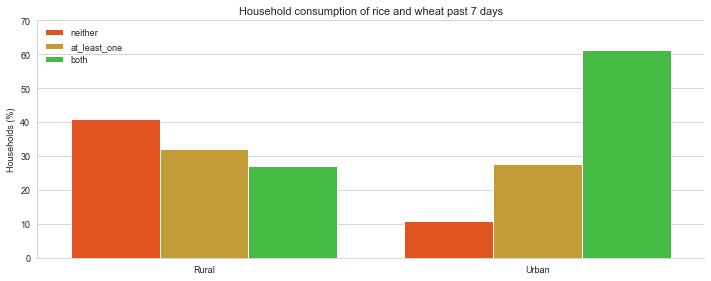

In [29]:
# HH Consumed wheat/rice during the last 7 days
# Urban/Rural
x,y = 'urbrur', 'hh_wheat_rice'
wheat_rice_urbrur = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,palette={"neither": "orangered",\
                                                           "at_least_one": "goldenrod", "both": 'limegreen'},\
      kind='bar', height=4, aspect=2.5, legend=False)
plt.xlabel("", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of rice and wheat past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,70])
plt.legend(frameon=False, prop={'size':9})
wheat_rice_urbrur.savefig('./OUTPUT_FINAL/Charts/wheat_rice_urbrur.svg')

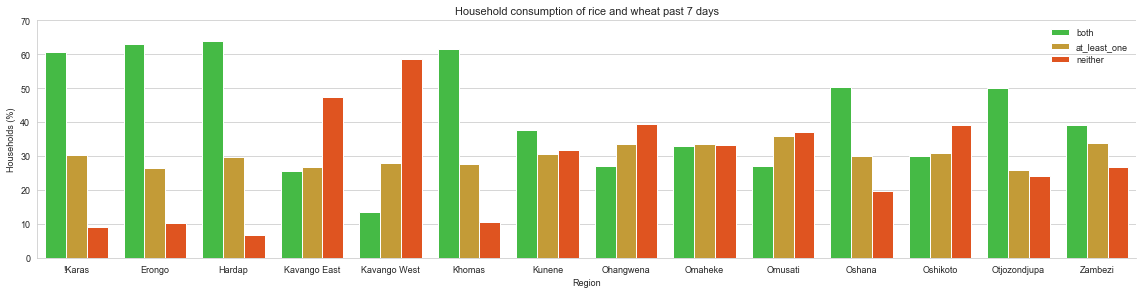

In [30]:
# Region
x,y = 'region', 'hh_wheat_rice'
wheat_rice_region = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"neither": "orangered", "at_least_one": "goldenrod", "both": 'limegreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Region", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of rice and wheat past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,70])
plt.legend(frameon=False, prop={'size':9})
wheat_rice_region.savefig('./OUTPUT_FINAL/Charts/wheat_rice_region.svg')

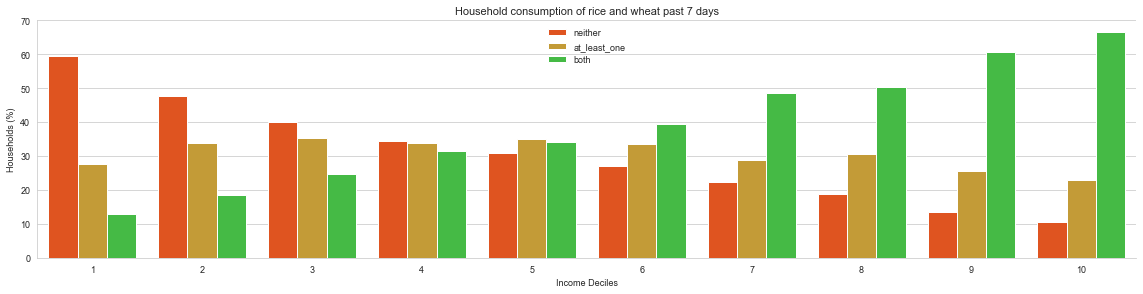

In [31]:
# Income
x,y = 'apci_dec', 'hh_wheat_rice'
wheat_rice_income = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"neither": "orangered", "at_least_one": "goldenrod", "both": 'limegreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Income Deciles", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of rice and wheat past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,70])
plt.legend(frameon=False, prop={'size':9})
wheat_rice_income.savefig('./OUTPUT_FINAL/Charts/wheat_rice_income.svg')

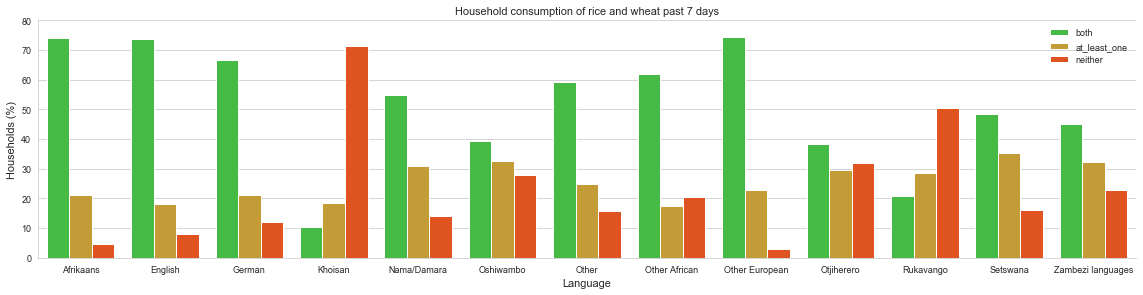

In [32]:
# Language
x,y = 'main_language', 'hh_wheat_rice'
wheat_rice_language = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"neither": "orangered", "at_least_one": "goldenrod", "both": 'limegreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Language", fontsize=11)
plt.ylabel("Households (%)", fontsize=11)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of rice and wheat past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,80])
plt.legend(frameon=False, prop={'size':9})
wheat_rice_language.savefig('./OUTPUT_FINAL/Charts/wheat_rice_language.svg')

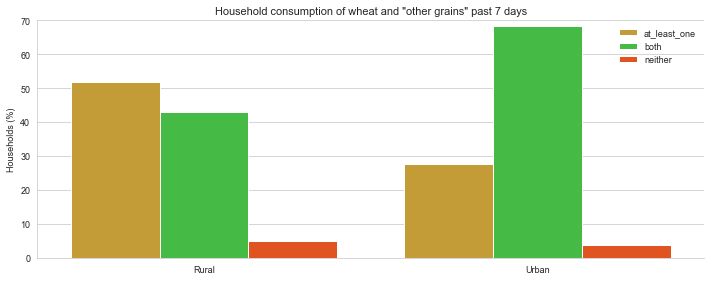

In [33]:
# HH Consumed wheat/other during the last 7 days
# Urban/Rural
x,y = 'urbrur', 'hh_wheat_other'
wheat_other_urbrur = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,palette={"neither": "orangered",\
                                                           "at_least_one": "goldenrod", "both": 'limegreen'},\
      kind='bar', height=4, aspect=2.5, legend=False)
plt.xlabel("", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of wheat and "other grains" past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,70])
plt.legend(frameon=False, prop={'size':9})
wheat_other_urbrur.savefig('./OUTPUT_FINAL/Charts/wheat_other_urbrur.svg')

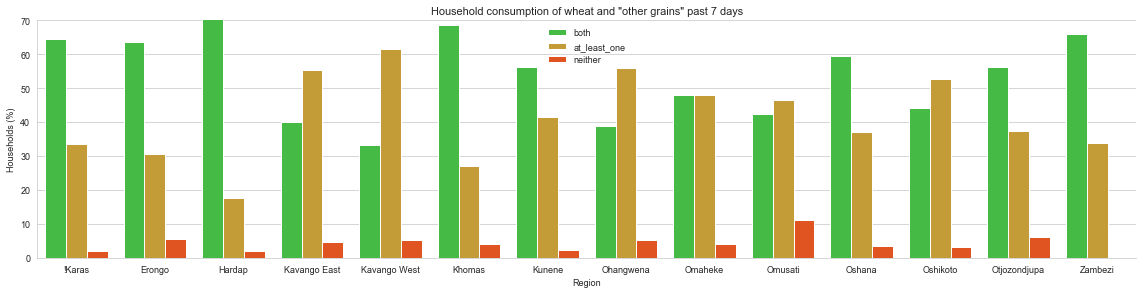

In [34]:
# Region
x,y = 'region', 'hh_wheat_other'
wheat_other_region = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"neither": "orangered", "at_least_one": "goldenrod", "both": 'limegreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Region", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of wheat and "other grains" past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,70])
plt.legend(frameon=False, prop={'size':9})
wheat_other_region.savefig('./OUTPUT_FINAL/Charts/wheat_other_region.svg')

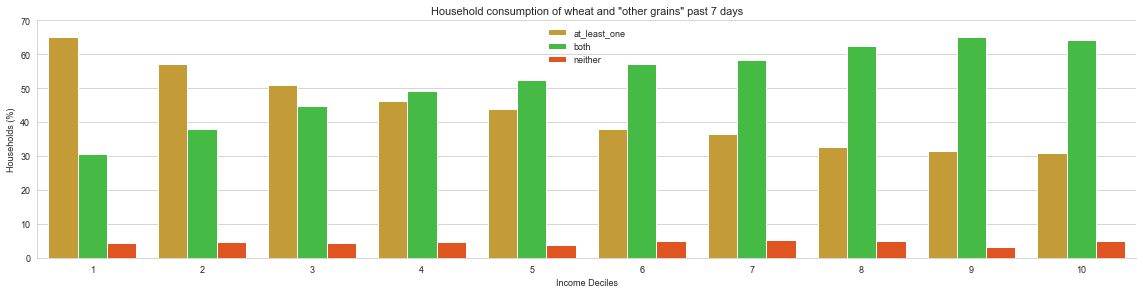

In [35]:
# Income
x,y = 'apci_dec', 'hh_wheat_other'
wheat_other_income = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"neither": "orangered", "at_least_one": "goldenrod", "both": 'limegreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Income Deciles", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of wheat and "other grains" past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,70])
plt.legend(frameon=False, prop={'size':9}, loc='upper center')
wheat_other_income.savefig('./OUTPUT_FINAL/Charts/wheat_other_income.svg')

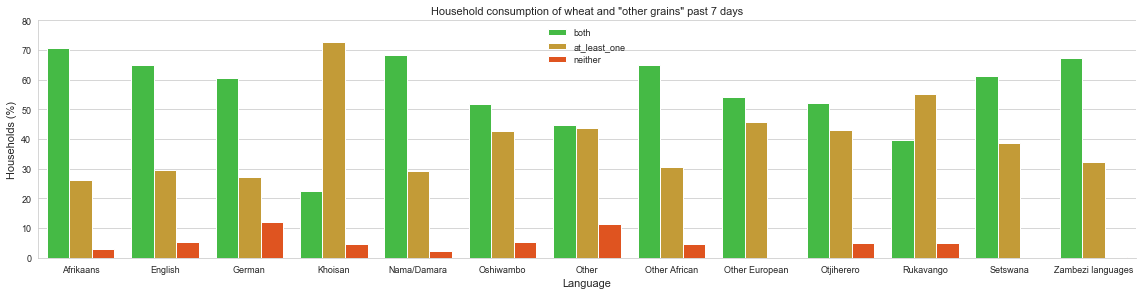

In [36]:
# Language
x,y = 'main_language', 'hh_wheat_other'
wheat_other_language = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"neither": "orangered", "at_least_one": "goldenrod", "both": 'limegreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Language", fontsize=11)
plt.ylabel("Households (%)", fontsize=11)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of wheat and "other grains" past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,80])
plt.legend(frameon=False, prop={'size':9})
wheat_other_language.savefig('./OUTPUT_FINAL/Charts/wheat_other_language.svg')

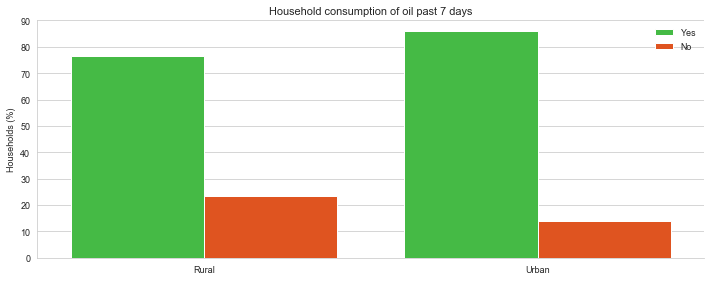

In [37]:
# Oil
# Urban/Rural
x,y = 'urbrur', 'hh_oil'
oil_urbrur = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"Yes": "limegreen", "No": 'orangered'},\
      kind='bar', height=4, aspect=2.5, legend=False)
plt.xlabel("", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of oil past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,90])
plt.legend(frameon=False, prop={'size':9})
oil_urbrur.savefig('./OUTPUT_FINAL/Charts/oil_urbrur.svg')

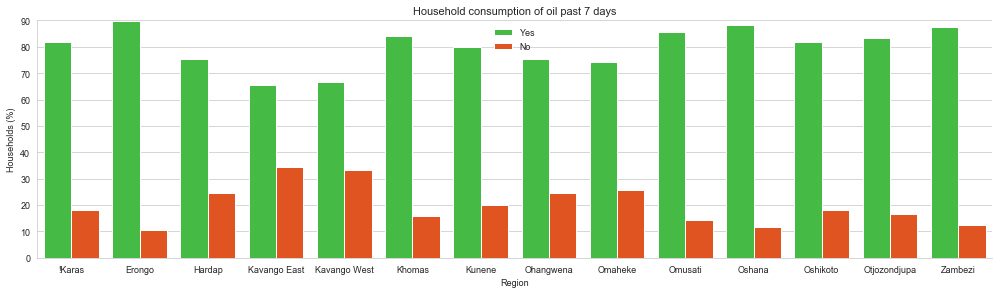

In [38]:
# Oil
# Region
x,y = 'region', 'hh_oil'
oil_region = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"Yes": "limegreen", "No": 'orangered'},\
      kind='bar', height=4, aspect=3.5, legend=False)
plt.xlabel("Region", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of oil past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,90])
plt.legend(frameon=False, prop={'size':9})
oil_region.savefig('./OUTPUT_FINAL/Charts/oil_region.svg')

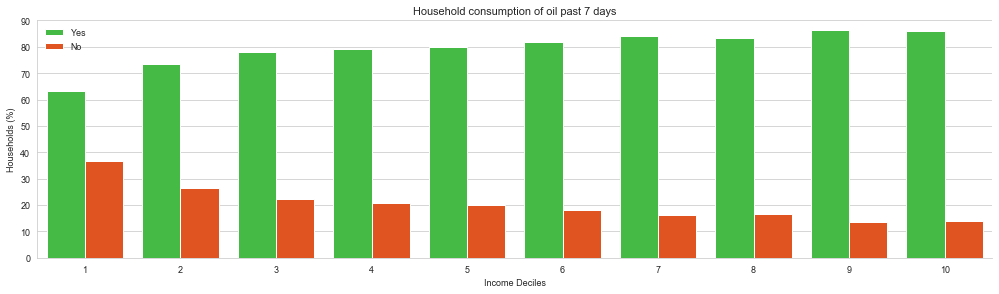

In [39]:
# Oil
# Income
x,y = 'apci_dec', 'hh_oil'
oil_income = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"Yes": "limegreen", "No": 'orangered'},\
      kind='bar', height=4, aspect=3.5, legend=False)
plt.xlabel("Income Deciles", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of oil past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,90])
plt.legend(frameon=False, prop={'size':9})
oil_income.savefig('./OUTPUT_FINAL/Charts/oil_income.svg')

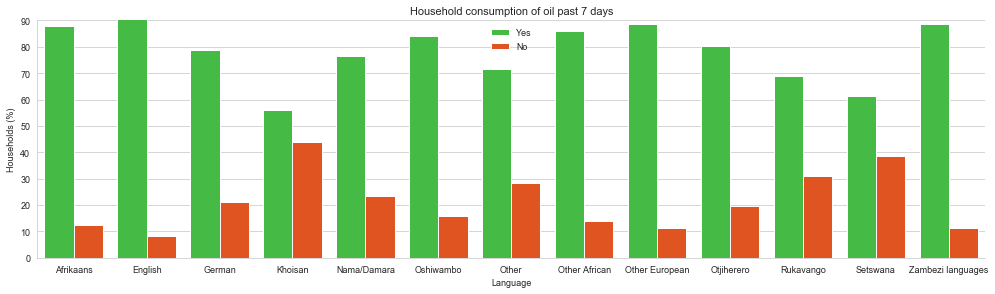

In [40]:
# Oil
# Main Language
x,y = 'main_language', 'hh_oil'
oil_language = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"Yes": "limegreen", "No": 'orangered'},\
      kind='bar', height=4, aspect=3.5, legend=False)
plt.xlabel("Language", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of oil past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,90])
plt.legend(frameon=False, prop={'size':9})
oil_language.savefig('./OUTPUT_FINAL/Charts/oil_language.svg')

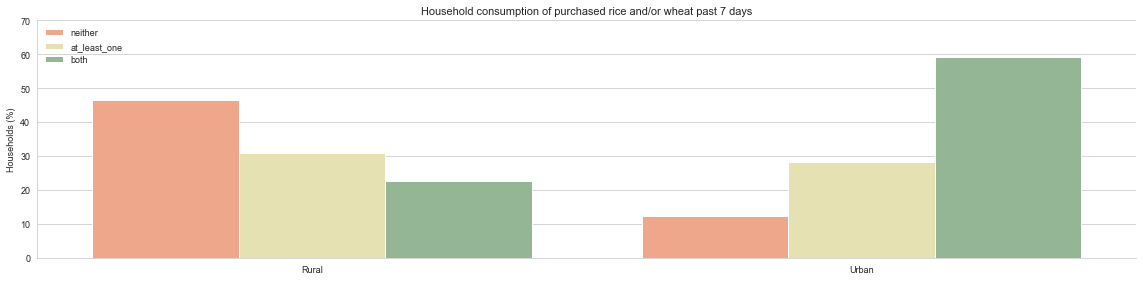

In [41]:
# Urban/rural
x,y = 'urbrur', 'hh_source_wheat_rice_not_loc'
wheat_rice_not_loc_urbrur = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"neither": "lightsalmon", "at_least_one": "palegoldenrod", "both": 'darkseagreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of purchased rice and/or wheat past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,70])
plt.legend(frameon=False, prop={'size':9})
wheat_rice_not_loc_urbrur.savefig('./OUTPUT_FINAL/Charts/wheat_rice_not_loc_urbrur.svg')

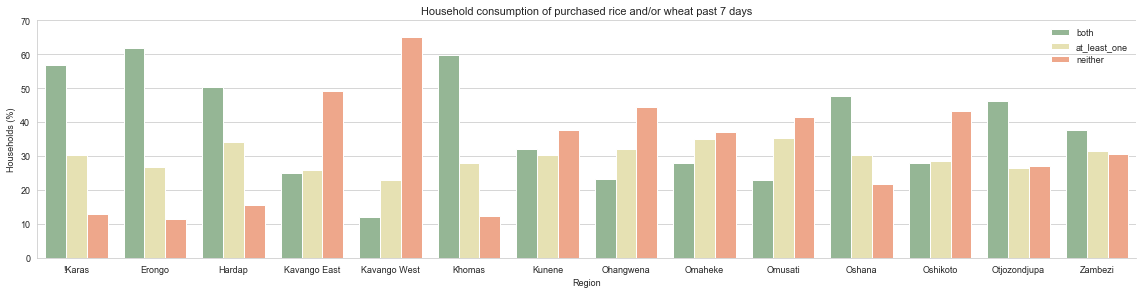

In [42]:
# Region
x,y = 'region', 'hh_source_wheat_rice_not_loc'
wheat_rice_not_loc_region = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"neither": "lightsalmon", "at_least_one": "palegoldenrod", "both": 'darkseagreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Region", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of purchased rice and/or wheat past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,70])
plt.legend(frameon=False, prop={'size':9})
wheat_rice_not_loc_region.savefig('./OUTPUT_FINAL/Charts/wheat_rice_not_loc_region.svg')

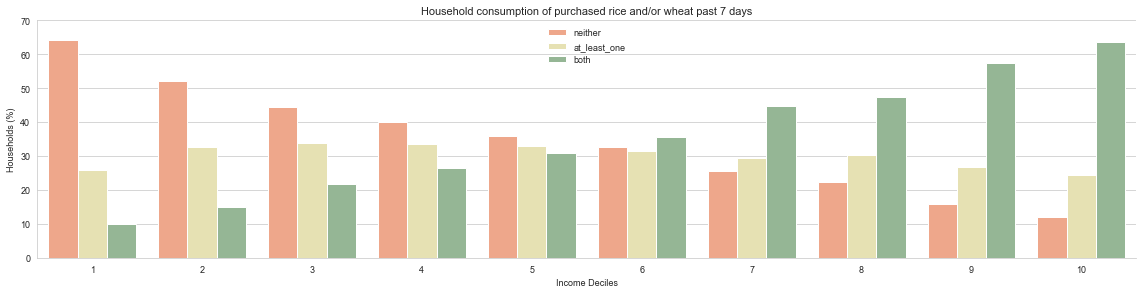

In [43]:
# Income
x,y = 'apci_dec', 'hh_source_wheat_rice_not_loc'
wheat_rice_not_loc_income = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"neither": "lightsalmon", "at_least_one": "palegoldenrod", "both": 'darkseagreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Income Deciles", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of purchased rice and/or wheat past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,70])
plt.legend(frameon=False, prop={'size':9})
wheat_rice_not_loc_income.savefig('./OUTPUT_FINAL/Charts/wheat_rice_not_loc_income.svg')

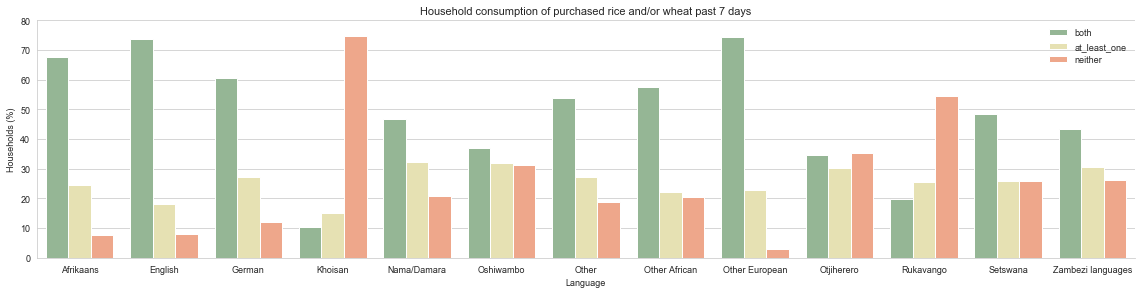

In [44]:
# Language
x,y = 'main_language', 'hh_source_wheat_rice_not_loc'
wheat_rice_not_loc_language = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"neither": "lightsalmon", "at_least_one": "palegoldenrod", "both": 'darkseagreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Language", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of purchased rice and/or wheat past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,80])
plt.legend(frameon=False, prop={'size':9})
wheat_rice_not_loc_language.savefig('./OUTPUT_FINAL/Charts/wheat_rice_not_loc_language.svg')

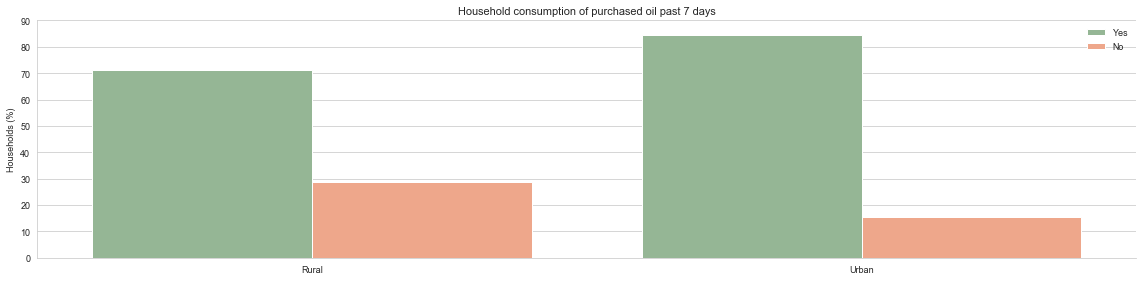

In [45]:
# Purhcased oil
# Urban
x,y = 'urbrur', 'hh_source_oil_not_loc'
oil_not_loc_urbrur = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"No": "lightsalmon", "Yes": 'darkseagreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of purchased oil past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,90])
plt.legend(frameon=False, prop={'size':9})
oil_not_loc_urbrur.savefig('./OUTPUT_FINAL/Charts/oil_not_loc_urbrur.svg')

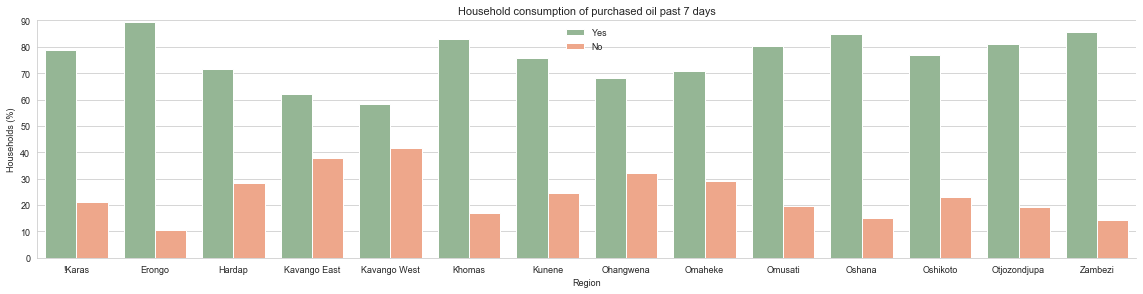

In [46]:
# Purhcased oil
# Region
x,y = 'region', 'hh_source_oil_not_loc'
oil_not_loc_region = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"No": "lightsalmon", "Yes": 'darkseagreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Region", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of purchased oil past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,90])
plt.legend(frameon=False, prop={'size':9})
oil_not_loc_region.savefig('./OUTPUT_FINAL/Charts/oil_not_loc_region.svg')

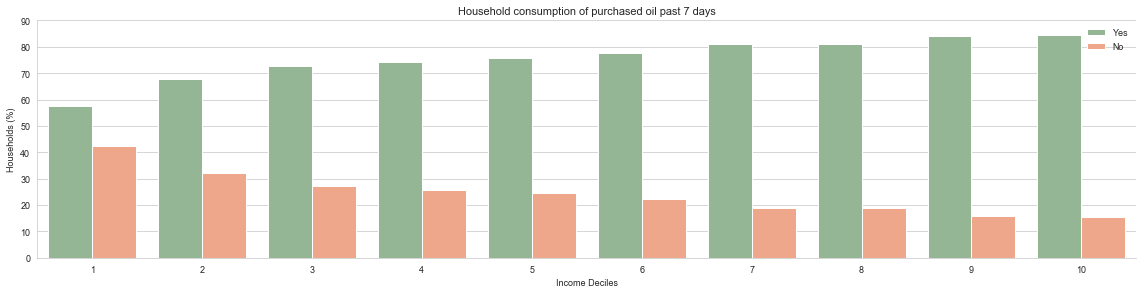

In [47]:
# Purhcased oil
# Income
x,y = 'apci_dec', 'hh_source_oil_not_loc'
oil_not_loc_income = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"No": "lightsalmon", "Yes": 'darkseagreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Income Deciles", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of purchased oil past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,90])
plt.legend(frameon=False, prop={'size':9})
oil_not_loc_income.savefig('./OUTPUT_FINAL/Charts/oil_not_loc_income.svg')

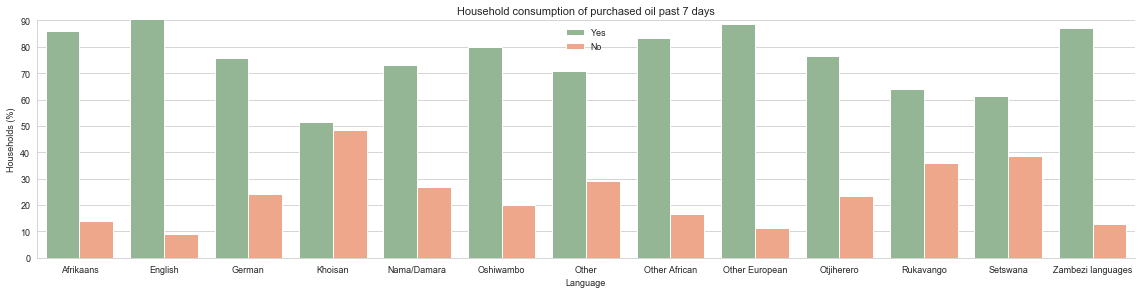

In [48]:
# Purhcased oil
# Language
x,y = 'main_language', 'hh_source_oil_not_loc'
oil_not_loc_language = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"No": "lightsalmon", "Yes": 'darkseagreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Language", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household consumption of purchased oil past 7 days',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,90])
plt.legend(frameon=False, prop={'size':9})
oil_not_loc_language.savefig('./OUTPUT_FINAL/Charts/oil_not_loc_language.svg')

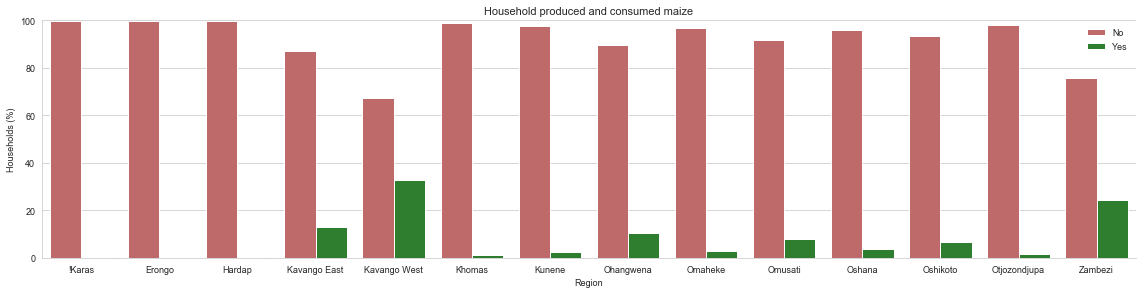

In [49]:
# HH Produced and consumed own maize
# Region
x,y = 'region', 'hh_maize_prod_cons'
maize_prod_cons_region = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"No": "indianred", "Yes": 'forestgreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Region", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household produced and consumed maize',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,100])
plt.legend(frameon=False, prop={'size':9})
maize_prod_cons_region.savefig('./OUTPUT_FINAL/Charts/maize_prod_cons_region.svg')

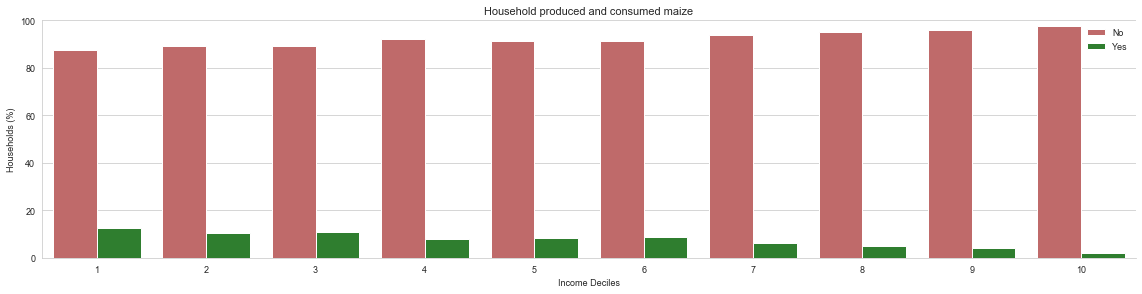

In [50]:
# HH Produced and consumed own maize
# Income
x,y = 'apci_dec', 'hh_maize_prod_cons'
maize_prod_cons_income = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"No": "indianred", "Yes": 'forestgreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Income Deciles", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household produced and consumed maize',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,100])
plt.legend(frameon=False, prop={'size':9})
maize_prod_cons_income.savefig('./OUTPUT_FINAL/Charts/maize_prod_cons_income.svg')

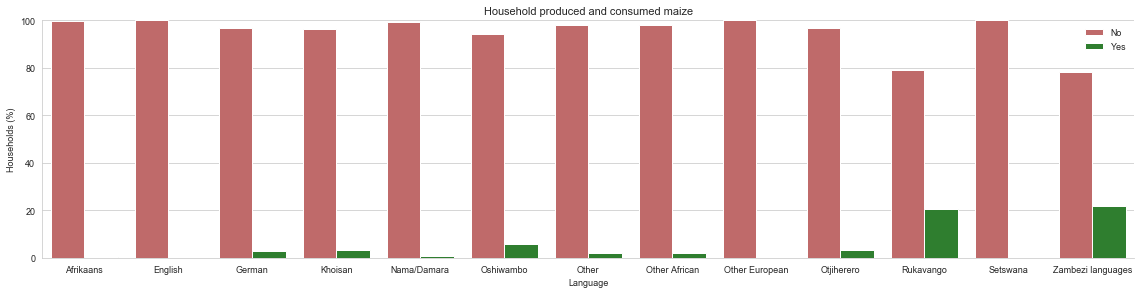

In [51]:
# HH Produced and consumed own maize
# Language
x,y = 'main_language', 'hh_maize_prod_cons'
maize_prod_cons_language = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"No": "indianred", "Yes": 'forestgreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Language", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household produced and consumed maize',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,100])
plt.legend(frameon=False, prop={'size':9})
maize_prod_cons_language.savefig('./OUTPUT_FINAL/Charts/maize_prod_cons_language.svg')

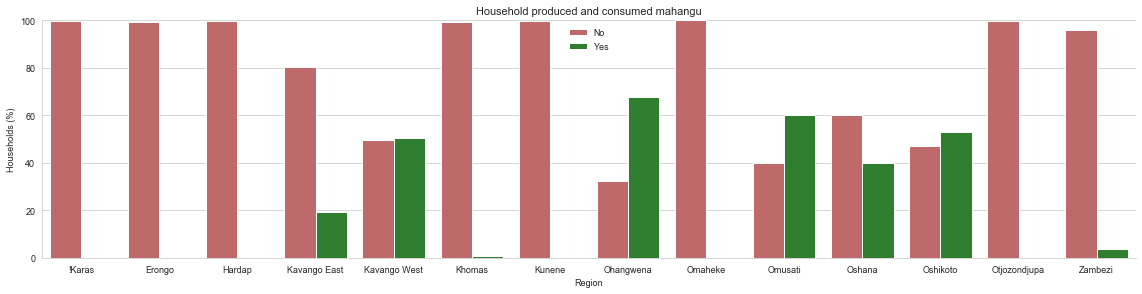

In [52]:
# HH Produced and consumed own mahangu
# Region
x,y = 'region', 'hh_mahangu_prod_cons'
mahangu_prod_cons_region = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"No": "indianred", "Yes": 'forestgreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Region", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household produced and consumed mahangu',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,100])
plt.legend(frameon=False, prop={'size':9})
mahangu_prod_cons_region.savefig('./OUTPUT_FINAL/Charts/mahangu_prod_cons_region.svg')

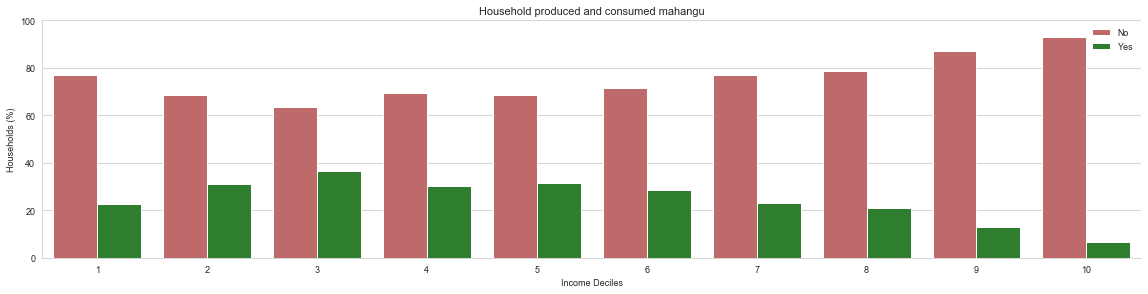

In [53]:
# HH Produced and consumed own mahangu
# Income
x,y = 'apci_dec', 'hh_mahangu_prod_cons'
mahangu_prod_cons_income = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"No": "indianred", "Yes": 'forestgreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Income Deciles", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household produced and consumed mahangu',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,100])
plt.legend(frameon=False, prop={'size':9})
mahangu_prod_cons_income.savefig('./OUTPUT_FINAL/Charts/mahangu_prod_cons_income.svg')

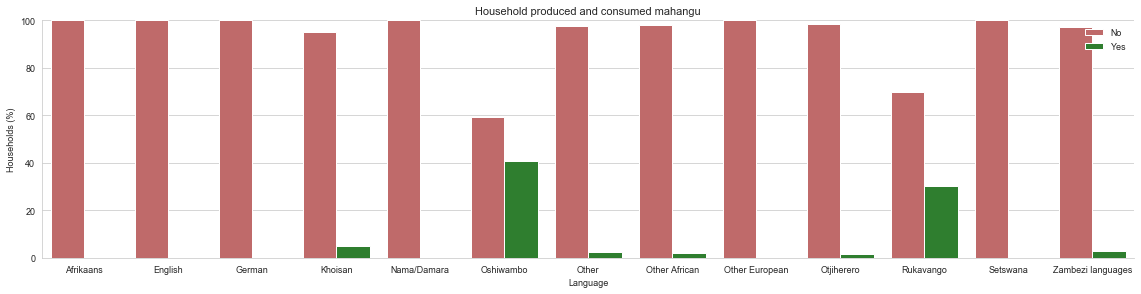

In [54]:
# HH Produced and consumed own mahangu
# Language
x,y = 'main_language', 'hh_mahangu_prod_cons'
mahangu_prod_cons_language = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"No": "indianred", "Yes": 'forestgreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Language", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household produced and consumed mahangu',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,100])
plt.legend(frameon=False, prop={'size':9})
mahangu_prod_cons_language.savefig('./OUTPUT_FINAL/Charts/mahangu_prod_cons_language.svg')

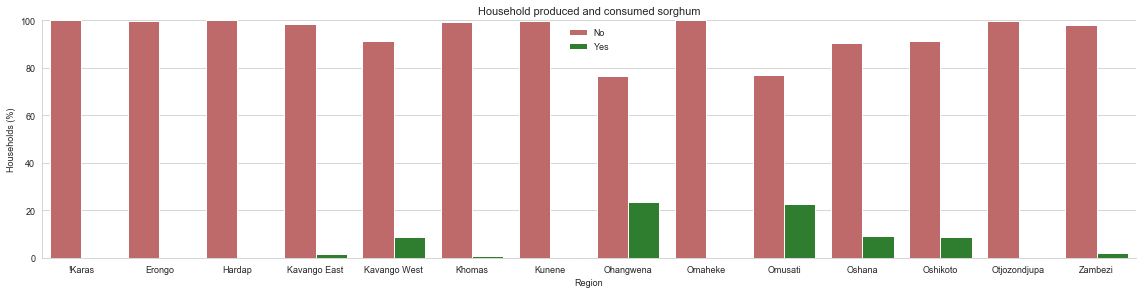

In [55]:
# HH Produced and consumed own sorghum
# Region
x,y = 'region', 'hh_sorghum_prod_cons'
sorghum_prod_cons_region = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"No": "indianred", "Yes": 'forestgreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Region", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household produced and consumed sorghum',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,100])
plt.legend(frameon=False, prop={'size':9})
sorghum_prod_cons_region.savefig('./OUTPUT_FINAL/Charts/sorghum_prod_cons_region.svg')

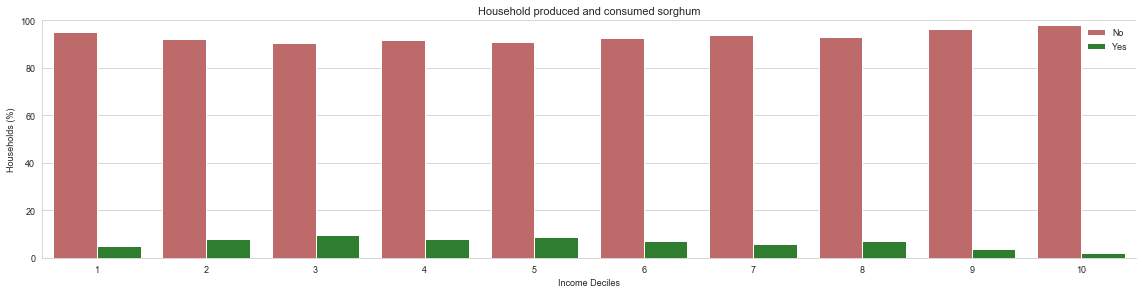

In [56]:
# HH Produced and consumed own sorghum
# Income
x,y = 'apci_dec', 'hh_sorghum_prod_cons'
sorghum_prod_cons_income = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"No": "indianred", "Yes": 'forestgreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Income Deciles", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household produced and consumed sorghum',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,100])
plt.legend(frameon=False, prop={'size':9})
sorghum_prod_cons_income.savefig('./OUTPUT_FINAL/Charts/sorghum_prod_cons_income.svg')

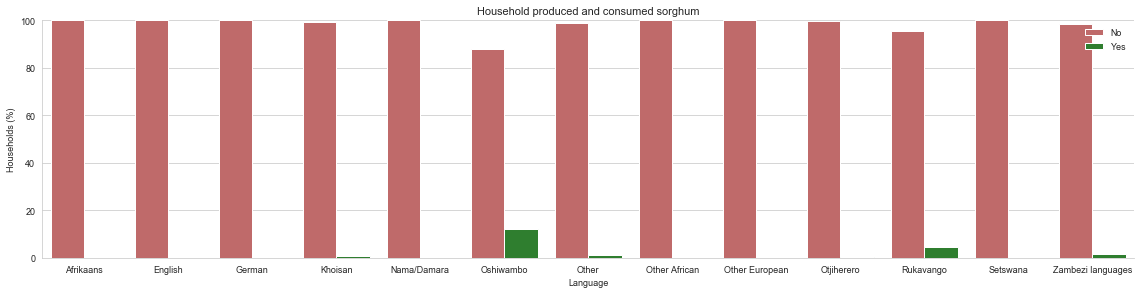

In [57]:
# HH Produced and consumed own sorghum
# Language
x,y = 'main_language', 'hh_sorghum_prod_cons'
sorghum_prod_cons_language = df.groupby(x)[y].value_counts(normalize=True).mul(100)\
.rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,\
      palette={"No": "indianred", "Yes": 'forestgreen'},\
      kind='bar', height=4, aspect=4, legend=False)
plt.xlabel("Language", fontsize=9)
plt.ylabel("Households (%)", fontsize=9)
plt.xticks(fontsize=9), plt.yticks(fontsize=9), plt.title('Household produced and consumed sorghum',fontsize=11)
axes = plt.gca()
axes.set_ylim([0,100])
plt.legend(frameon=False, prop={'size':9})
sorghum_prod_cons_language.savefig('./OUTPUT_FINAL/Charts/sorghum_prod_cons_language.svg')